# Region Coverage Validation: Sentinel-2

The other validation notebooks test TAT-C's observations of points. This notebook tests its observations of regions, with `collect_region_observations` and `collect_multi_region_observations`: a region (a polygon or multipolygon) is observed while the instrument's footprint intersects any part of it, and each observation records its start and end, its swath (the part of the region swept by the footprint), and a hash identifying the region (`target_hash`). The reference is the acquisitions of the Copernicus [Sentinel-2](https://sentiwiki.copernicus.eu/web/s2-mission) Multispectral Instrument (MSI) over six countries during one of the constellation's 10-day repeat cycles, from 14 to 24 September 2026, by Sentinel-2B and 2C, whose acquisition plans include every pass over land (Sentinel-2A's reduced plan does not; see the [Sentinel-2 revisit](ValidateRevisitSentinel2.ipynb) notebook). The countries exercise the handling of region geometry:

* **Iceland**, a single polygon at high latitude;
* **Japan**, a multipolygon of islands;
* **Chile**, a long, narrow region spanning 38 deg of latitude (with Tierra del Fuego);
* **Fiji**, a multipolygon across the anti-meridian;
* **Norway**, a multipolygon reaching 80.7 deg north (with Svalbard); and
* **Switzerland**, a small landlocked region, narrower than the swath is long.

The comparison asks three questions:

1. **Passes.** Does `collect_multi_region_observations` predict the passes on which each satellite imaged any part of each region?
2. **Periods and swaths.** Do the observation periods start and end when the instrument's footprint first and last intersects the region, and do the swaths contain the parts of the region within the footprints?
3. **Revisit and coverage.** Do the sample counts and revisit periods from `aggregate_observations` and `reduce_observations` match those observed, and do the swaths cover each region over the repeat cycle?

## Reference Data

The [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a) catalog of Sentinel-2 Level 2A products (anonymous access) is searched for every product whose valid data footprint intersects each region during the analysis period. Each product is a 110 km tile of one acquisition (datatake); the datatake identifies the satellite and the time at which the acquisition started (the catalog does not record the time each part of a region was imaged). An observed pass of a region is a datatake with at least one product intersecting it. The regions are the Natural Earth 1:110 million country polygons, whose coastlines are accurate to a few kilometers. Search results are cached in a local `data/sentinel2` directory.

The satellites are modeled with TLEs from [CelesTrak](https://celestrak.org/) whose epochs (4 October 2026) follow the end of the analysis period by 10 days; the revisit notebook finds that, propagated 20 days back, these TLEs are within 11 km (2B) and 3 km (2C) of the satellites' GPS positions.

In [1]:
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import cartopy.io.shapereader as shpreader
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "sentinel2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 14, tzinfo=timezone.utc)
END = datetime(2026, 9, 24, tzinfo=timezone.utc)
STAC = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
TLES = {
    "Sentinel-2B": [
        "1 42063U 17013A   26277.50820593  .00000133  00000+0  67483-4 0  9991",
        "2 42063  98.5691 350.7118 0001149  89.0927 271.0388 14.30818478500277",
    ],
    "Sentinel-2C": [
        "1 60989U 24157A   26277.47326514  .00000038  00000+0  31260-4 0  9993",
        "2 60989  98.5703 350.6835 0001156  81.8213 278.3101 14.30817151108611",
    ],
}
PLATFORMS = list(TLES)
REGION_NAMES = ["Iceland", "Japan", "Chile", "Fiji", "Norway", "Switzerland"]

countries = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries"))
regions = {r.attributes["NAME"]: r.geometry for r in countries.records() if r.attributes["NAME"] in REGION_NAMES}
regions = {name: regions[name] for name in REGION_NAMES}
REGION_IDS = {name: i for i, name in enumerate(REGION_NAMES)}


def search(name, region):
    """Catalog products whose valid data footprint intersects a region during the analysis period."""
    cache = DATA_DIR / f"region_search_{name}_{START:%Y%m%d}_{END:%Y%m%d}.json"
    if cache.exists():
        return json.loads(cache.read_text())
    body = {
        "collections": ["sentinel-2-l2a"],
        "intersects": region.__geo_interface__,
        "datetime": f"{START:%Y-%m-%dT%H:%M:%SZ}/{END - timedelta(seconds=1):%Y-%m-%dT%H:%M:%SZ}",
        "limit": 1000,
        "fields": {"include": ["id", "properties.platform", "properties.s2:datatake_id"], "exclude": ["geometry"]},
    }
    rows = []
    while body is not None:
        for attempt in range(8):
            try:
                response = requests.post(STAC, json=body, timeout=300)
                response.raise_for_status()
                page = response.json()
                break
            except (requests.RequestException, ValueError):
                if attempt == 7:
                    raise
                # back off (the catalog limits request rates)
                time.sleep(2**attempt)
        rows += [
            {"region": name, "product": f["id"], "platform": f["properties"]["platform"], "datatake": f["properties"]["s2:datatake_id"]}
            for f in page["features"]
        ]
        following = [link for link in page.get("links", []) if link.get("rel") == "next"]
        body = following[0].get("body") if following else None
    cache.write_text(json.dumps(rows))
    return rows


products = pd.DataFrame([row for name, region in regions.items() for row in search(name, region)])
products["datatake_start"] = pd.to_datetime(products.datatake.str.extract(r"_(\d{8}T\d{6})_")[0], format="%Y%m%dT%H%M%S", utc=True)
observed = (
    products[products.platform.isin(PLATFORMS)]
    .groupby(["region", "platform", "datatake"], as_index=False)
    .agg(datatake_start=("datatake_start", "first"), products=("product", "size"))
    .sort_values(["region", "datatake_start"], ignore_index=True)
)
products.groupby(["region", "platform"]).agg(products=("product", "size"), passes=("datatake", "nunique")).unstack(fill_value=0).reindex(REGION_NAMES)

products                              passes              \
platform    Sentinel-2A Sentinel-2B Sentinel-2C Sentinel-2A Sentinel-2B   
region                                                                    
Iceland              84          84          83           7           7   
Japan                68         154         152           3           7   
Chile               173         299         279           4           7   
Fiji                  0          14          13           0           2   
Norway              566         570         503          33          32   
Switzerland          28          29          31           4           4   

                         
platform    Sentinel-2C  
region                   
Iceland               7  
Japan                 7  
Chile                 7  
Fiji                  2  
Norway               28  
Switzerland           4

## Setup

MSI is modeled as in the [Sentinel-2 revisit](ValidateRevisitSentinel2.ipynb) notebook: a rectangular `PointedInstrument` spanning cross-track view angles of -10.56 to +10.54 deg (a 290 km swath), with a 1 deg along-track field of view. `collect_region_observations` searches for the periods when its footprint intersects each region, within the periods when its field of regard (31.1 deg) may observe the region. It requires the target to be sunlit (`req_target_sunlit`), evaluated at each observation's midpoint at a point of the region within the footprint, which excludes the night-side passes. Each region is identified by its hash (`hash_geometry`).

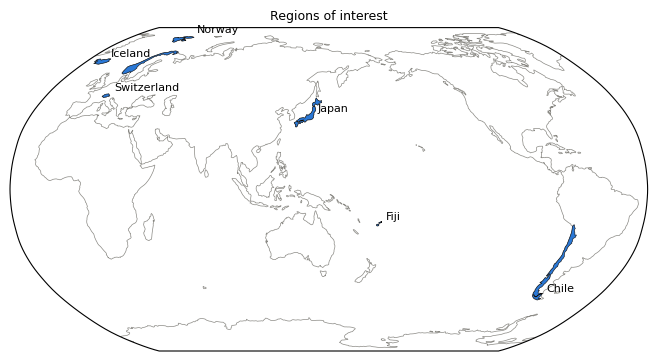

In [2]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt

from tatc.analysis import aggregate_observations, collect_ground_track, collect_multi_region_observations, reduce_observations
from skyfield.api import wgs84

from tatc.constants import de421, timescale
from tatc.schemas import GeneralPerturbationsOrbit, PointedInstrument, Satellite
from tatc.utils import hash_geometry, split_polygon

msi = PointedInstrument(
    name="MSI",
    field_of_regard=31.1,
    cross_track_field_of_view=21.1,
    along_track_field_of_view=1,
    roll_angle=-0.01,
    is_rectangular=True,
    req_target_sunlit=True,
)
SPLIT_REGIONS = {name: split_polygon(region) for name, region in regions.items()}
REGION_NAMES_BY_HASH = {hash_geometry(region): name for name, region in regions.items()}
satellites = {name: Satellite(name=name, orbit=GeneralPerturbationsOrbit.from_tle(tle), instruments=[msi]) for name, tle in TLES.items()}


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
PLATFORM_COLORS = dict(zip(PLATFORMS, [ORANGE, AQUA]))
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

fig = plt.figure(figsize=(12, 4.2))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=150))
ax.set_global()
ax.coastlines(color=GRAY, linewidth=0.5)
ax.add_geometries(list(regions.values()), crs=ccrs.PlateCarree(), facecolor=BLUE, edgecolor=INK, linewidth=0.4)
for name, region in regions.items():
    point = region.representative_point()
    ax.annotate(name, (point.x, point.y), xytext=(6, 4), textcoords="offset points", fontsize=8, transform=ccrs.PlateCarree())
ax.set_title("Regions of interest", fontsize=9)
plt.show()

## Test 1: Passes

`collect_multi_region_observations` predicts the observations of each region by each satellite. A region may be observed more than once on one pass, as the swath crosses separate parts of it (such as islands) with gaps between them, so consecutive observations by the same satellite less than 10 minutes apart (a satellite's consecutive passes are 100 minutes apart) are grouped into a predicted pass. A predicted pass matches an observed pass if it is by the same satellite and the datatake started no more than 45 minutes before the predicted pass began (the longest day-side datatakes last about 40 minutes) and no more than 1 minute after it ended.

In [3]:
def solar_elevation(row, instrument):
    """Solar elevation (deg) at an observation's midpoint, at the point of the region within the footprint at which TAT-C checks illumination."""
    midpoint = (row.start + (row.end - row.start) / 2).round("us").to_pydatetime()
    orbit_track = satellites[row.platform].orbit.to_gp_orbit().get_orbit_track([midpoint])
    region = SPLIT_REGIONS[row.region]
    view = instrument.compute_footprint(orbit_track)[0].intersection(region)
    point = (view if not view.is_empty else region).representative_point()
    topos = de421["earth"] + wgs84.latlon(point.y, point.x)
    return topos.at(timescale.from_datetime(midpoint)).observe(de421["sun"]).apparent().altaz()[0].degrees


def predict(instrument=msi):
    """Predicted observations of each region by each satellite, grouped into passes."""
    members = [s.model_copy(update={"instruments": [instrument]}) for s in satellites.values()]
    frames = []
    for name, region in regions.items():
        o = collect_multi_region_observations(region, members, START, END)
        frames.append(o.assign(region=name).rename(columns={"satellite": "platform"}))
    o = pd.concat(frames, ignore_index=True).sort_values(["region", "platform", "start"], ignore_index=True)
    o["solar_alt"] = [solar_elevation(row, instrument) for row in o.itertuples()]
    new_pass = (o.region != o.region.shift()) | (o.platform != o.platform.shift()) | (o.start - o.end.shift() > pd.Timedelta(minutes=10))
    o["pass"] = new_pass.cumsum()
    return o


def passes(o):
    """Predicted passes: the span of each group of observations."""
    return o.groupby("pass").agg(
        region=("region", "first"), platform=("platform", "first"), start=("start", "min"), end=("end", "max"),
        observations=("start", "size"), solar_alt=("solar_alt", "max"),
    ).reset_index()


def match(predicted_passes):
    """Match predicted passes to observed passes (datatakes) of the same region and satellite."""
    pairs = predicted_passes.merge(observed, on=["region", "platform"])
    pairs = pairs[(pairs.datatake_start >= pairs.start - pd.Timedelta(minutes=45)) & (pairs.datatake_start <= pairs.end + pd.Timedelta(minutes=1))]
    p = predicted_passes.assign(acquired=predicted_passes["pass"].isin(pairs["pass"]))
    o = observed.assign(predicted=observed.set_index(["region", "datatake"]).index.isin(pairs.set_index(["region", "datatake"]).index))
    return p, o


predicted = predict()
predicted_passes, observed1 = match(passes(predicted))
table1 = pd.DataFrame(
    {
        "observed passes": observed1.groupby("region").size(),
        "observed passes predicted": observed1.groupby("region").predicted.sum(),
        "predicted passes": predicted_passes.groupby("region").size(),
        "predicted passes acquired": predicted_passes.groupby("region").acquired.sum(),
        "predicted observations": predicted.groupby("region").size(),
    }
).reindex(REGION_NAMES).fillna(0).astype(int)
table1.loc["total"] = table1.sum()
table1

,observed passes,observed passes predicted,predicted passes,predicted passes acquired,predicted observations
region,,,,,
Iceland,14,14,14,14,14
Japan,14,14,14,14,20
Chile,14,14,14,14,20
Fiji,4,4,4,4,8
Norway,60,60,88,58,98
Switzerland,8,8,8,8,8
total,114,114,142,112,168


Over the 10 days, Sentinel-2B and 2C imaged parts of the six regions on 114 passes, and TAT-C predicts every one of them, including those of Fiji, across the anti-meridian, and of Svalbard, at 80 deg north. Of TAT-C's 142 predicted passes, 112 were acquired: every predicted pass of Iceland, Japan, Chile, Fiji, and Switzerland, and 58 of Norway's 88.

On some passes, the swath crosses separate parts of a region, so the 142 predicted passes comprise 168 observations: 20 of Japan's islands on 14 passes, 20 of Chile on 14, 8 of Fiji's islands on 4, and 98 of Norway (including Svalbard) on 88. Norway's 60 observed passes match 58 predicted passes because on two passes (by 2C on 15 September and by 2B on 20 September) the acquisition over Norway was split into two datatakes, about 4 minutes apart.

The predicted passes that were not acquired are classified, in order, as:

* **low Sun**: the solar elevation, at the observation's midpoint at the point of the region within the footprint where TAT-C checks illumination, is below 10 deg (TAT-C's `req_target_sunlit` only requires it to be above 0 deg);
* **swath edge**: the pass is not predicted with a cross-track field of view of 20.4 deg, the swath in which all bands have valid data; and
* **other**.

In [4]:
# swath edge: passes not predicted with the cross-track field of view of the
# swath in which all bands have valid data (+/-10.2 deg)
narrow = predict(msi.model_copy(update={"name": "MSI (valid swath)", "cross_track_field_of_view": 20.4}))
narrow_passes = passes(narrow)
overlap = predicted_passes.merge(narrow_passes, on=["region", "platform"], suffixes=("", "_narrow"))
overlap = overlap[(overlap.start_narrow <= overlap.end) & (overlap.end_narrow >= overlap.start)]
predicted_passes["cause"] = "acquired"
missed = ~predicted_passes.acquired
predicted_passes.loc[missed & (predicted_passes.solar_alt < 10), "cause"] = "low Sun"
predicted_passes.loc[missed & (predicted_passes.cause == "acquired") & ~predicted_passes["pass"].isin(overlap["pass"]), "cause"] = "swath edge"
predicted_passes.loc[missed & (predicted_passes.cause == "acquired"), "cause"] = "other"
causes1 = predicted_passes.groupby(["region", "cause"]).size().unstack(fill_value=0).reindex(index=REGION_NAMES, columns=["acquired", "low Sun", "swath edge", "other"], fill_value=0)
causes1.loc["total"] = causes1.sum()
causes1

cause,acquired,low Sun,swath edge,other
region,,,,
Iceland,14,0,0,0
Japan,14,0,0,0
Chile,14,0,0,0
Fiji,4,0,0,0
Norway,58,30,0,0
Switzerland,8,0,0,0
total,112,30,0,0


In [5]:
# solar elevation (deg) at the region within the footprint, of acquired and other predicted passes
display(predicted_passes.groupby("cause").solar_alt.describe().round(1))
# predicted passes not acquired, and observed passes not predicted
display(predicted_passes[predicted_passes.cause != "acquired"][["region", "platform", "start", "end", "observations", "solar_alt", "cause"]])
display(observed1[~observed1.predicted][["region", "platform", "datatake", "datatake_start", "products"]])

,count,mean,std,min,25%,50%,75%,max
cause,,,,,,,,
acquired,112.0,28.0,16.7,5.9,11.7,26.3,43.4,62.7
low Sun,30.0,3.4,2.1,0.0,1.7,3.1,5.1,7.2


,region,platform,start,end,observations,solar_alt,cause
49,Norway,Sentinel-2B,2026-09-14 15:57:22.094406744+00:00,2026-09-14 15:57:55.101099883+00:00,1,4.417593,low Sun
50,Norway,Sentinel-2B,2026-09-14 17:36:44.326996354+00:00,2026-09-14 17:37:41.376861188+00:00,1,0.020384,low Sun
54,Norway,Sentinel-2B,2026-09-15 15:27:30.779881163+00:00,2026-09-15 15:28:01.591471511+00:00,1,5.226035,low Sun
55,Norway,Sentinel-2B,2026-09-15 17:07:02.992326966+00:00,2026-09-15 17:07:49.903446207+00:00,1,1.358229,low Sun
60,Norway,Sentinel-2B,2026-09-16 16:37:12.789035694+00:00,2026-09-16 16:37:55.804328735+00:00,1,2.262336,low Sun
64,Norway,Sentinel-2B,2026-09-17 16:07:20.503671942+00:00,2026-09-17 16:07:55.323551808+00:00,1,2.883974,low Sun
68,Norway,Sentinel-2B,2026-09-18 15:37:28.877152723+00:00,2026-09-18 15:37:59.709328087+00:00,1,3.643297,low Sun
72,Norway,Sentinel-2B,2026-09-19 15:07:38.095087904+00:00,2026-09-19 15:08:08.490773371+00:00,1,4.452089,low Sun
73,Norway,Sentinel-2B,2026-09-19 16:47:11.157017764+00:00,2026-09-19 16:47:55.205344070+00:00,1,0.724493,low Sun
77,Norway,Sentinel-2B,2026-09-20 16:17:18.839444334+00:00,2026-09-20 16:17:53.214150038+00:00,1,1.296095,low Sun


,region,platform,datatake,datatake_start,products


All 30 predicted passes that were not acquired are of Norway, between 13:58 and 17:37 UTC, when the Sun was 0.0 to 7.2 deg above the horizon; the acquired passes had solar elevations of 5.9 to 63 deg. As in the [Sentinel-2 revisit](ValidateRevisitSentinel2.ipynb) notebook, Sentinel-2's acquisition plan does not image at such a low Sun, which `req_target_sunlit` does not model. A minimum target solar elevation (`min_target_solar_elevation`) would remove most of these passes, but not cleanly: for a region, it is evaluated at a single point and time, and two acquired passes had solar elevations below 7.2 deg there. No predicted pass was missed at the swath edge or otherwise, and every observed pass was predicted.

## Test 2: Periods and Swaths

The catalog does not record when each part of a region was imaged, so the observation periods and swaths are compared with TAT-C's footprints, computed independently with `collect_ground_track`, with each region as a mask. Footprints are sampled every 0.1 s within 2 s of each observation's start and end (observations of the same region are at least 4.3 s apart), and the first and last footprints that intersect the region are compared with the start and end.

In [6]:
def footprint_times(row, center):
    """Times, at 0.1 s intervals within 2 s of a time, at which the footprint intersects the region."""
    center = center.round("us")
    times = pd.date_range(center - pd.Timedelta(seconds=2), center + pd.Timedelta(seconds=2), freq="100ms").to_pydatetime().tolist()
    return collect_ground_track(satellites[row.platform], times, mask=regions[row.region]).time


def footprint_period(row):
    """First footprint intersecting the region near the start, and last near the end."""
    first, last = footprint_times(row, row.start), footprint_times(row, row.end)
    return pd.Series({"first": first.min() if len(first) else pd.NaT, "last": last.max() if len(last) else pd.NaT})


periods2 = pd.concat([predicted, predicted.apply(footprint_period, axis=1)], axis=1)
periods2["start difference (s)"] = (periods2["first"] - periods2.start).dt.total_seconds()
periods2["end difference (s)"] = (periods2.end - periods2["last"]).dt.total_seconds()
periods2["duration (s)"] = (periods2.end - periods2.start).dt.total_seconds()
print("observations without an intersecting footprint:", int(periods2["first"].isna().sum()))
pd.DataFrame({column: summarize(periods2[column]) for column in ["duration (s)", "start difference (s)", "end difference (s)"]}).T

observations without an intersecting footprint: 0


,n,median,p95 |x|,max |x|
duration (s),168.0,4.872098e+01,233.4573,533.635159
start difference (s),168.0,2.530000e-07,0.1000,0.100000
end difference (s),168.0,9.999951e-02,0.1000,0.100000


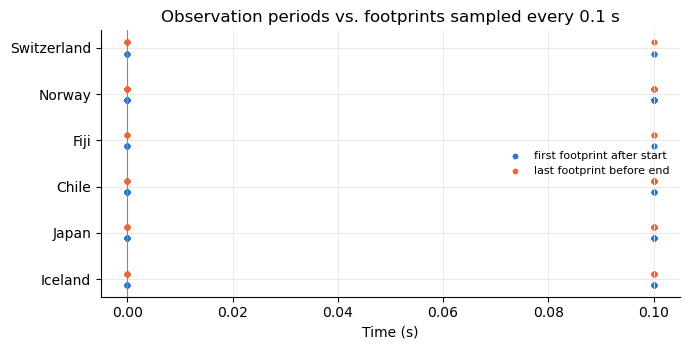

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for k, (name, frame) in enumerate(periods2.groupby("region", sort=False)):
    y = np.full(len(frame), REGION_IDS[name])
    ax.scatter(frame["start difference (s)"], y - 0.12, s=10, color=BLUE, label="first footprint after start" if k == 0 else None)
    ax.scatter(frame["end difference (s)"], y + 0.12, s=10, color=ORANGE, label="last footprint before end" if k == 0 else None)
ax.set_yticks(range(len(REGION_NAMES)), REGION_NAMES)
ax.axvline(0, color=GRAY, lw=0.8)
ax.set(xlabel="Time (s)", title="Observation periods vs. footprints sampled every 0.1 s")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
import shapely

# overlays on a 1e-9 deg (0.1 mm) precision grid: overlays of the nearly coincident
# edges of footprints and swaths are otherwise unstable (to several km2)
GRID = 1e-9


def polygonal(geometry):
    """Polygonal parts of a geometry (an overlay on a precision grid can leave lines or points)."""
    parts = shapely.get_parts(shapely.get_parts(geometry))
    return shapely.MultiPolygon([part for part in parts if part.geom_type == "Polygon"])


def footprint_union(row):
    """Union of the footprints sampled every 1 s over an observation (and at its end), clipped to the region."""
    start, end = row.start.round("us"), row.end.round("us")
    times = pd.date_range(start, end, freq="1s").to_pydatetime().tolist() + [end.to_pydatetime()]
    track = collect_ground_track(satellites[row.platform], times, mask=regions[row.region])
    if not len(track):
        return None
    return polygonal(shapely.union_all(track.geometry.to_numpy(), grid_size=GRID).intersection(SPLIT_REGIONS[row.region], grid_size=GRID))


EQUAL_AREA = "EPSG:6933"


def area(geometries):
    """Area (km2) in an equal-area projection."""
    return gpd.GeoSeries(geometries, crs="EPSG:4326").to_crs(EQUAL_AREA).area.to_numpy() / 1e6


sampled = [footprint_union(row) for row in predicted.itertuples()]
swath_area = area(predicted.geometry)
snapped = [polygonal(shapely.set_precision(g, GRID)) for g in predicted.geometry]
missing = area([s.difference(g, grid_size=GRID) for s, g in zip(sampled, snapped)])
extra = area([g.difference(s, grid_size=GRID) for s, g in zip(sampled, snapped)])
swaths3 = pd.DataFrame(
    {
        "swath area (km2)": swath_area,
        "sampled not in swath (km2)": missing,
        "sampled not in swath (%)": 100 * missing / swath_area,
        "swath not sampled (km2)": extra,
        "swath not sampled (%)": 100 * extra / swath_area,
    }
)
pd.DataFrame({column: summarize(swaths3[column]) for column in swaths3.columns}).T

,n,median,p95 |x|,max |x|
swath area (km2),168.0,19647.176498,213466.654557,525097.478387
sampled not in swath (km2),168.0,0.017265,0.142673,0.343591
sampled not in swath (%),168.0,0.000055,0.001609,0.006649
swath not sampled (km2),168.0,2.159216,15.098988,21.283853
swath not sampled (%),168.0,0.007993,0.181669,5.631931


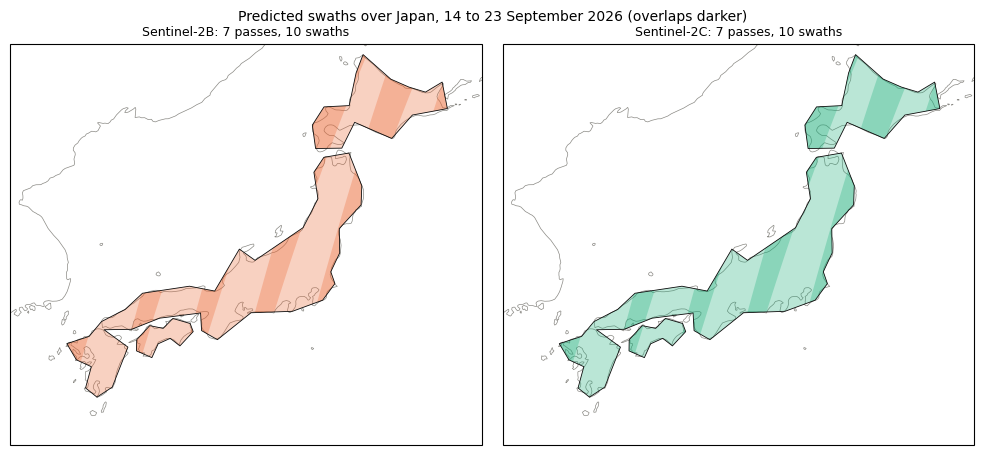

In [9]:
name = "Japan"
frame = predicted[predicted.region == name]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, platform in zip(axes, PLATFORMS):
    ax.set_extent([127, 147, 29, 46], crs=ccrs.PlateCarree())
    ax.coastlines(color=GRAY, linewidth=0.5)
    swaths = frame[frame.platform == platform]
    ax.add_geometries(swaths.geometry, crs=ccrs.PlateCarree(), facecolor=PLATFORM_COLORS[platform], edgecolor="none", alpha=0.3)
    ax.add_geometries([regions[name]], crs=ccrs.PlateCarree(), facecolor="none", edgecolor=INK, linewidth=0.6)
    ax.set_title(f"{platform}: {swaths['pass'].nunique()} passes, {len(swaths)} swaths", fontsize=9)
fig.suptitle(f"Predicted swaths over {name}, {START:%d} to {END - timedelta(days=1):%d %B %Y} (overlaps darker)", fontsize=10)
fig.tight_layout()
plt.show()

Every one of the 168 predicted observations, which last from 2.6 s to 8.9 minutes, has footprints intersecting the region near its start and end, and the first and last of them are within the 0.1 s sampling of the observation's start and end, for every region geometry.

The swaths are compared with the union of footprints sampled every 1 s over each observation, clipped to the region (with overlays on a 1e-9 deg precision grid, since overlays of nearly coincident edges are otherwise unstable). The sampled footprints lie within the swaths (to within 0.007% of a swath's area, or 0.3 km2), and the swaths exceed the sampled footprints by 0.008% (median) of their area, at most 21 km2, as they also contain the area swept between samples; the largest relative difference, 5.6%, is of a 3 km2 swath of Norway's coast that the footprint crosses in 2.6 s. The maps show the swaths of Japan, whose 14 passes divide into 20 observations of separate islands.

## Test 3: Revisit and Coverage

For each region, the observed passes (at their datatake start times) and the predicted passes (at their midpoints) are aggregated with `aggregate_observations` and reduced with `reduce_observations` to a number of samples and a mean revisit period. Observations of a region are grouped by its hash (`target_hash`). Because the datatake start precedes the imaging time by up to 40 minutes, revisit periods are compared in days.

In [10]:
def as_observations(frame, time_column):
    """A data frame of instantaneous observations of regions, as accepted by aggregate_observations."""
    t = frame[time_column]
    return gpd.GeoDataFrame(
        {
            "target_hash": [hash_geometry(regions[name]) for name in frame.region],
            "geometry": [regions[name] for name in frame.region],
            "satellite": frame.platform.to_numpy(),
            "instrument": "MSI",
            "start": t.to_numpy(),
            "end": t.to_numpy(),
        },
        crs="EPSG:4326",
    )


def revisit_statistics(frame):
    reduced = reduce_observations(aggregate_observations(frame))
    reduced["region"] = reduced.target_hash.map(REGION_NAMES_BY_HASH)
    reduced["revisit (days)"] = reduced.revisit.dt.total_seconds() / 86400
    return reduced.set_index("region")[["samples", "revisit (days)"]].reindex(REGION_NAMES)


midpoints = predicted_passes.assign(midpoint=predicted_passes.start + (predicted_passes.end - predicted_passes.start) / 2)
o3 = revisit_statistics(as_observations(observed1, "datatake_start"))
p3 = revisit_statistics(as_observations(midpoints, "midpoint"))
a3 = revisit_statistics(as_observations(midpoints[midpoints.acquired], "midpoint"))
pd.concat({"observed": o3, "predicted": p3, "predicted, acquired passes": a3}, axis=1).round(2)

observed                predicted                 \
             samples revisit (days)   samples revisit (days)   
region                                                         
Iceland           14           0.69        14           0.69   
Japan             14           0.69        14           0.69   
Chile             14           0.69        14           0.69   
Fiji               4           2.67         4           2.67   
Norway            60           0.15        88           0.11   
Switzerland        8           1.29         8           1.29   

            predicted, acquired passes                 
                               samples revisit (days)  
region                                                 
Iceland                             14           0.69  
Japan                               14           0.69  
Chile                               14           0.69  
Fiji                                 4           2.67  
Norway                              58           0.16  
Switzerland                          8           1.29

In [11]:
def coverage(frame):
    """Percentage of the area of each region within the union of its swaths (see reduce_observations)."""
    reduced = reduce_observations(aggregate_observations(frame.rename(columns={"platform": "satellite"})[["target_hash", "geometry", "satellite", "instrument", "start", "end"]]))
    reduced["region"] = reduced.target_hash.map(REGION_NAMES_BY_HASH)
    return pd.Series(100 * area(reduced.geometry) / area([SPLIT_REGIONS[name] for name in reduced.region]), index=reduced.region).reindex(REGION_NAMES)


acquired = predicted["pass"].isin(predicted_passes.loc[predicted_passes.acquired, "pass"])
pd.DataFrame({"predicted passes": coverage(predicted), "predicted passes, acquired": coverage(predicted[acquired])}).round(1).rename_axis("region coverage (%)", axis=1)

region coverage (%),predicted passes,"predicted passes, acquired"
region,,
Iceland,100.0,100.0
Japan,100.0,100.0
Chile,100.0,100.0
Fiji,100.0,100.0
Norway,100.0,100.0
Switzerland,100.0,100.0


For Iceland, Japan, Chile, Fiji, and Switzerland, the predicted sample counts and mean revisit periods equal those observed: 14 samples with a mean revisit of 0.69 days for each of Iceland, Japan, and Chile, 8 samples and 1.29 days for Switzerland, and 4 samples and 2.67 days for Fiji. For Norway, TAT-C predicts 88 samples with a mean revisit of 0.11 days, against 60 observed with 0.15 days: the difference is the 30 low-Sun passes. Restricted to the predicted passes that were acquired, the prediction is 58 samples and 0.16 days (the two remaining observed samples are the second datatakes of split acquisitions).

Reduced, the predicted observations of each region have as geometry the union of its swaths, which covers all of each region (to within 0.02% of its area, in an equal-area projection), with or without the low-Sun passes: Sentinel-2B and 2C image all land every 5 days.

## Summary

| Test | Result |
| --- | --- |
| 1. Passes (`collect_multi_region_observations`) | all 114 observed passes of the six regions predicted; 112 of 142 predicted passes acquired; the other 30, all of Norway, at solar elevations of 0.0 to 7.2 deg, below Sentinel-2's acquisition plan |
| 2. Periods and swaths | observation starts and ends within the 0.1 s sampling of the first and last footprints intersecting each region; swaths contain the sampled footprints, exceeding them by 0.008% (median) with the area swept between samples |
| 3. Revisit and coverage (`aggregate_observations`, `reduce_observations`) | sample counts and mean revisit periods equal to those observed for five of six regions; Norway's 88 predicted samples (60 observed) include the 30 low-Sun passes; swaths cover every region over the 10 days |

`collect_region_observations` predicts when Sentinel-2 images any part of a region, and which part, for single polygons and multipolygons, across the anti-meridian, and at high latitude, with observation periods and swaths consistent with the instrument's footprints. As for points, its predictions assume that every pass in view is acquired: here, with Sentinel-2's acquisition plan, every sunlit pass except at a low Sun.